In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import librosa
import os

In [2]:
df_preds = pd.read_csv('voicebio_predictions.csv')

In [3]:
df_preds.head()

,id,year,true_age,pred_age,abs_error
0,id00021,2020,33,28.96,4.04
1,id00021,2019,32,30.26,1.74
2,id00021,2022,35,35.00,0.00
3,id00021,2021,34,31.37,2.63
4,id00021,2023,36,31.08,4.92


In [4]:
df_preds['error'] = df_preds['pred_age'] - df_preds['true_age']  
df_preds['abs_error'] = abs(df_preds['error'])                  
df_preds['squared_error'] = df_preds['error'] ** 2              

# Метрики
MAE = abs(df_preds['pred_age'] - df_preds['true_age']).mean()
MSE = ((df_preds['pred_age'] - df_preds['true_age'])**2).mean()
RMSE = np.sqrt(MSE)
STD_ERROR = (df_preds['pred_age'] - df_preds['true_age']).std()

# Дополнительные метрики в пределах
within_10_years = (df_preds['abs_error'] <= 10).mean() * 100
within_5_years = (df_preds['abs_error'] <= 5).mean() * 100
within_3_years = (df_preds['abs_error'] <= 3).mean() * 100
within_1_year = (df_preds['abs_error'] <= 1).mean() * 100

print("Метрики оценки")

print(f"\nОсновные метрики:")
print(f"MAE  (Mean Absolute Error):     {MAE:.3f} лет")
print(f"RMSE (Root Mean Squared Error): {RMSE:.3f} лет")
print(f"Std of Error (разброс ошибок):  {STD_ERROR:.3f} лет")

print(f"\nПроцент ошибок в пределах:")
print(f"  ≤ 1 год:   {within_1_year:.1f}%")
print(f"  ≤ 3 года:  {within_3_years:.1f}%")
print(f"  ≤ 5 лет:   {within_5_years:.1f}%")
print(f"  ≤ 10 лет:   {within_10_years:.1f}%")

print(f"\nСтатистика абсолютных ошибок:")
print(f"  Мин ошибка:  {df_preds['abs_error'].min():.3f} лет")
print(f"  Медиана:     {df_preds['abs_error'].median():.3f} лет")
print(f"  Макс ошибка: {df_preds['abs_error'].max():.3f} лет")

Метрики оценки

Основные метрики:
MAE  (Mean Absolute Error):     5.536 лет
RMSE (Root Mean Squared Error): 7.949 лет
Std of Error (разброс ошибок):  7.755 лет

Процент ошибок в пределах:
  ≤ 1 год:   13.1%
  ≤ 3 года:  39.6%
  ≤ 5 лет:   58.0%
  ≤ 10 лет:   88.4%

Статистика абсолютных ошибок:
  Мин ошибка:  0.000 лет
  Медиана:     3.820 лет
  Макс ошибка: 40.360 лет


Macro MAE

In [ ]:
# Создаем возрастные группы
bins = [0, 20, 40, 60, 70]
labels = ['0-20', '20-40', '40-60', '60+']

df_preds['age_group'] = pd.cut(df_preds['true_age'], bins=bins, labels=labels, right=False)

mae_by_group = df_preds.groupby('age_group')['abs_error'].mean()

# Макро MAE
macro_mae = mae_by_group.mean()

weighted_mae = (df_preds.groupby('age_group')['abs_error']
                         .agg(['mean', 'count'])
                         .assign(weighted=lambda x: x['mean'] * x['count'] / x['count'].sum())
                         ['weighted'].sum())

print(f"MAE по возрастным группам:\n")
print(mae_by_group)
print(f"\nMacro MAE: {macro_mae:.3f} лет")
print(f"MAE: {weighted_mae:.3f} лет")

MAE по возрастным группам:

age_group
0-20     10.272500
20-40     3.814429
40-60    12.115158
60+      31.335000
Name: abs_error, dtype: float64

Macro MAE: 14.384 лет
MAE: 5.536 лет


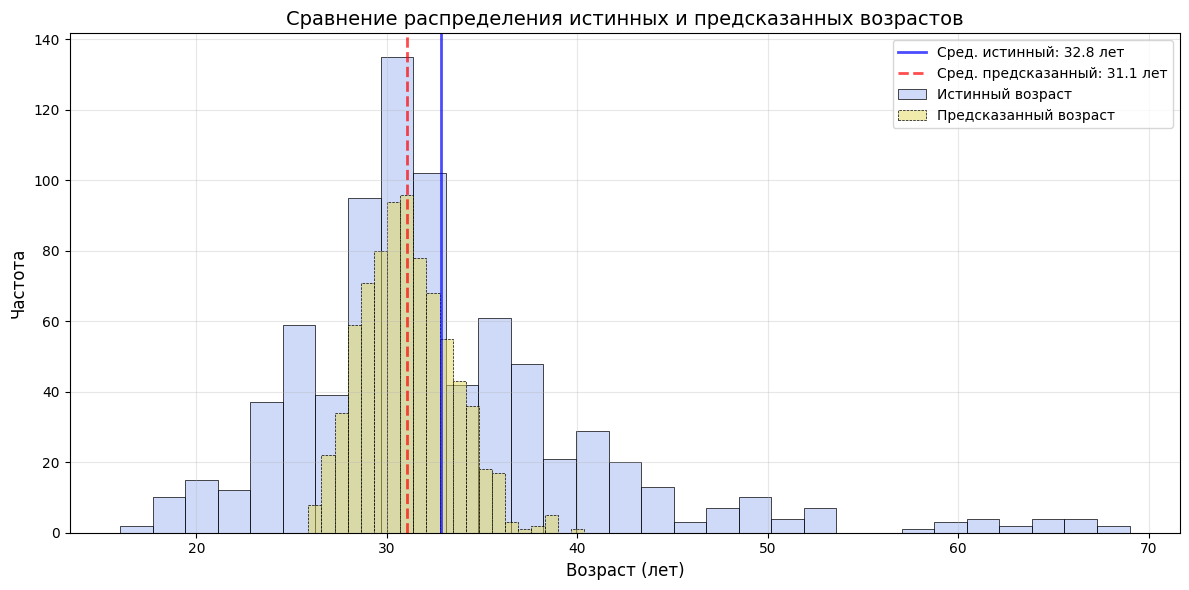

In [5]:
plt.figure(figsize=(12, 6))

sns.histplot(data=df_preds, x='true_age', 
             color='#A1B7F4', alpha=0.5, label='Истинный возраст',
             edgecolor='black', linewidth=0.5)
sns.histplot(data=df_preds, x='pred_age',
             color="#E3D958", alpha=0.5, label='Предсказанный возраст',
             edgecolor='black', linewidth=0.5, linestyle='--')

plt.axvline(df_preds['true_age'].mean(), color='blue', linestyle='-', linewidth=2, alpha=0.7,
           label=f'Сред. истинный: {df_preds["true_age"].mean():.1f} лет')
plt.axvline(df_preds['pred_age'].mean(), color='red', linestyle='--', linewidth=2, alpha=0.7,
           label=f'Сред. предсказанный: {df_preds["pred_age"].mean():.1f} лет')

plt.xlabel('Возраст (лет)', fontsize=12)
plt.ylabel('Частота', fontsize=12)
plt.title('Сравнение распределения истинных и предсказанных возрастов', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [6]:
df_preds.shape

(791, 7)